# Data Analysis V2: New_BKK_Data

Exploratory analysis for the PostgreSQL table `"New_BKK_Data"`, focused on finding the top 3 weather variables most correlated with `precipitation` so they can be prioritized for lag features.

## 1. Setup

Run the install cell only if your notebook kernel does not already have these packages.

In [29]:
# Optional: uncomment if needed.
# %pip install pandas psycopg2-binary matplotlib seaborn numpy

In [30]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)

## 2. Connect to PostgreSQL

The default values mirror the project scripts. Set `PGPASSWORD` in your environment if you do not want to keep the fallback password here.

In [31]:
DB_CONFIG = {
    "host": os.getenv("PGHOST", "localhost"),
    "port": int(os.getenv("PGPORT", "5432")),
    "dbname": os.getenv("PGDATABASE", "postgres"),
    "user": os.getenv("PGUSER", "postgres"),
    "password": os.getenv("PGPASSWORD", "Pass1234"),
}

TABLE_NAME = '"New_BKK_Data"'
TABLE_NAME_UNQUOTED = "New_BKK_Data"

conn = psycopg2.connect(**DB_CONFIG)
print("Connected to PostgreSQL")

Connected to PostgreSQL


In [32]:
def read_sql(query, params=None, parse_dates=None):
    return pd.read_sql_query(query, conn, params=params, parse_dates=parse_dates)

## 3. Table Structure and Coverage

In [33]:
schema_query = """
SELECT
    ordinal_position,
    column_name,
    data_type,
    is_nullable,
    column_default
FROM information_schema.columns
WHERE table_schema = 'public'
  AND table_name = %s
ORDER BY ordinal_position;
"""

schema_df = read_sql(schema_query, params=[TABLE_NAME_UNQUOTED])
schema_df

,ordinal_position,column_name,data_type,is_nullable,column_default
0,1,grid_number,integer,NO,NaN
1,2,grid_row,integer,NO,NaN
2,3,grid_column,integer,NO,NaN
3,4,longitude,double precision,NO,NaN
4,5,latitude,double precision,NO,NaN
5,6,forecast_time,timestamp with time zone,NO,NaN
6,7,temperature_2m,double precision,YES,NaN
7,8,cape,double precision,YES,NaN
8,9,dew_point_2m,double precision,YES,NaN
9,10,relative_humidity_2m,double precision,YES,NaN


In [34]:
coverage_query = f"""
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT grid_number) AS grid_count,
    MIN(forecast_time) AS min_forecast_time,
    MAX(forecast_time) AS max_forecast_time,
    MIN(fetched_at) AS min_fetched_at,
    MAX(fetched_at) AS max_fetched_at
FROM {TABLE_NAME};
"""

coverage_df = read_sql(
    coverage_query,
    parse_dates=["min_forecast_time", "max_forecast_time", "min_fetched_at", "max_fetched_at"],
)
coverage_df

,row_count,grid_count,min_forecast_time,max_forecast_time,min_fetched_at,max_fetched_at
0,2688000,56,2021-01-01 00:00:00+00:00,2026-06-23 23:00:00+00:00,2026-06-22 04:19:31.236660+00:00,2026-06-23 05:22:44.931239+00:00


In [35]:
sample_query = f"""
SELECT *
FROM {TABLE_NAME}
ORDER BY forecast_time DESC, grid_number
LIMIT 10;
"""

read_sql(sample_query, parse_dates=["forecast_time", "fetched_at"])

,grid_number,grid_row,grid_column,longitude,latitude,forecast_time,temperature_2m,cape,dew_point_2m,relative_humidity_2m,precipitation,cloud_cover,surface_pressure,wind_direction_10m,wind_speed_10m,convective_inhibition,pressure_msl,model,fetched_at
0,1,1,1,100.327,13.494,2026-06-23 23:00:00+00:00,27.500,1610.000,24.100,82.000,0.000,5.000,1007.700,247.000,8.800,59.000,1007.900,ecmwf_ifs,2026-06-23 05:22:09.671178+00:00
1,2,1,2,100.410,13.494,2026-06-23 23:00:00+00:00,28.800,1960.000,24.500,78.000,0.000,6.000,1007.900,251.000,12.900,27.000,1007.900,ecmwf_ifs,2026-06-23 05:22:09.671178+00:00
2,3,1,3,100.493,13.494,2026-06-23 23:00:00+00:00,28.800,1960.000,24.500,78.000,0.000,6.000,1007.900,251.000,12.900,27.000,1007.900,ecmwf_ifs,2026-06-23 05:22:09.671178+00:00
3,4,1,4,100.577,13.494,2026-06-23 23:00:00+00:00,29.000,2190.000,24.700,77.000,0.000,5.000,1008.000,259.000,11.500,13.000,1008.000,ecmwf_ifs,2026-06-23 05:22:09.671178+00:00
4,5,1,5,100.660,13.494,2026-06-23 23:00:00+00:00,29.000,2190.000,24.600,77.000,0.000,5.000,1008.000,259.000,11.500,13.000,1008.000,ecmwf_ifs,2026-06-23 05:22:09.671178+00:00
5,6,1,6,100.743,13.494,2026-06-23 23:00:00+00:00,28.300,2310.000,24.500,80.000,0.000,5.000,1008.000,265.000,9.400,12.000,1008.000,ecmwf_ifs,2026-06-23 05:22:09.671178+00:00
6,7,1,7,100.826,13.494,2026-06-23 23:00:00+00:00,27.900,2250.000,24.600,82.000,0.000,5.000,1007.900,271.000,7.400,17.000,1008.100,ecmwf_ifs,2026-06-23 05:22:09.671178+00:00
7,8,1,8,100.910,13.494,2026-06-23 23:00:00+00:00,27.600,2140.000,24.500,83.000,0.000,7.000,1007.900,277.000,6.300,23.000,1008.100,ecmwf_ifs,2026-06-23 05:22:09.671178+00:00
8,9,2,1,100.327,13.575,2026-06-23 23:00:00+00:00,26.300,1080.000,23.500,85.000,0.000,2.000,1007.200,246.000,5.300,111.000,1007.900,ecmwf_ifs,2026-06-23 05:22:09.671178+00:00
9,10,2,2,100.410,13.575,2026-06-23 23:00:00+00:00,27.000,1260.000,23.600,82.000,0.000,3.000,1007.900,252.000,7.200,88.000,1008.000,ecmwf_ifs,2026-06-23 05:22:09.671178+00:00


## 4. Load Data for Exploration

This loads every row from `"New_BKK_Data"` so the correlation ranking uses the full dataset.

In [36]:
data_query = f"""
SELECT *
FROM {TABLE_NAME}
ORDER BY forecast_time, grid_number;
"""

raw_df = read_sql(data_query, parse_dates=["forecast_time", "fetched_at"])

columns_to_drop_from_analysis = ["cape", "convective_inhibition"]
df = raw_df.drop(columns=columns_to_drop_from_analysis, errors="ignore").copy()

print(f"Raw shape: {raw_df.shape}")
print(f"Analysis shape after dropping {columns_to_drop_from_analysis}: {df.shape}")
df.head()

Raw shape: (2688000, 19)
Analysis shape after dropping ['cape', 'convective_inhibition']: (2688000, 17)


,grid_number,grid_row,grid_column,longitude,latitude,forecast_time,temperature_2m,dew_point_2m,relative_humidity_2m,precipitation,cloud_cover,surface_pressure,wind_direction_10m,wind_speed_10m,pressure_msl,model,fetched_at
0,1,1,1,100.327,13.494,2021-01-01 00:00:00+00:00,18.600,12.900,69.000,0.000,12.000,1015.300,15.000,10.800,1015.500,ecmwf_ifs,2026-06-23 02:04:19.284614+00:00
1,2,1,2,100.410,13.494,2021-01-01 00:00:00+00:00,19.000,12.800,68.000,0.000,15.000,1015.400,45.000,10.700,1015.400,ecmwf_ifs,2026-06-23 02:04:19.284614+00:00
2,3,1,3,100.493,13.494,2021-01-01 00:00:00+00:00,19.000,12.800,68.000,0.000,15.000,1015.400,45.000,10.700,1015.400,ecmwf_ifs,2026-06-23 02:04:19.284614+00:00
3,4,1,4,100.577,13.494,2021-01-01 00:00:00+00:00,18.600,11.400,63.000,0.000,16.000,1015.400,55.000,13.700,1015.400,ecmwf_ifs,2026-06-23 02:04:19.284614+00:00
4,5,1,5,100.660,13.494,2021-01-01 00:00:00+00:00,18.600,11.400,63.000,0.000,16.000,1015.400,55.000,13.700,1015.400,ecmwf_ifs,2026-06-23 02:04:19.284614+00:00


In [37]:
weather_columns = [
    "temperature_2m",
    "dew_point_2m",
    "relative_humidity_2m",
    "precipitation",
    "cloud_cover",
    "surface_pressure",
    "wind_direction_10m",
    "wind_speed_10m",
    "pressure_msl",
]

available_weather_columns = [column for column in weather_columns if column in df.columns]

df = df.copy()
df["forecast_hour"] = df["forecast_time"].dt.hour
df["forecast_date"] = df["forecast_time"].dt.date

df["rain_flag"] = df["precipitation"].fillna(0).gt(0)

raw_missing_dropped_columns = (
    raw_df[columns_to_drop_from_analysis]
    .isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_rate=lambda data: data["missing_count"] / len(raw_df))
)

print("Missingness in dropped columns:")
display(raw_missing_dropped_columns)

df.describe(include="all")

Missingness in dropped columns:


,missing_count,missing_rate
cape,2308936,0.859
convective_inhibition,2346683,0.873


,grid_number,grid_row,grid_column,longitude,latitude,forecast_time,temperature_2m,dew_point_2m,relative_humidity_2m,precipitation,cloud_cover,surface_pressure,wind_direction_10m,wind_speed_10m,pressure_msl,model,fetched_at,forecast_hour,forecast_date,rain_flag
count,2688000.000,2688000.000,2688000.000,2688000.000,2688000.000,2688000,2688000.000,2688000.000,2688000.000,2688000.000,2688000.000,2688000.000,2688000.000,2688000.000,2688000.000,2688000,2688000,2688000.000,2688000,2688000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,2000,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ecmwf_ifs,NaN,NaN,2021-01-01,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2688000,NaN,NaN,1344,2107509
mean,28.500,4.000,4.500,100.618,13.734,2023-09-27 23:30:00+00:00,27.947,22.695,74.957,0.197,71.082,1008.962,174.392,8.685,1009.291,NaN,2026-06-22 09:08:32.195853+00:00,11.500,NaN,NaN
min,1.000,1.000,1.000,100.327,13.494,2021-01-01 00:00:00+00:00,13.600,4.800,14.000,0.000,0.000,998.600,1.000,0.000,998.900,NaN,2026-06-22 04:19:31.236660+00:00,0.000,NaN,NaN
25%,14.750,2.000,2.750,100.473,13.575,2022-05-15 23:45:00+00:00,25.900,21.700,65.000,0.000,37.000,1006.800,96.000,5.400,1007.100,NaN,2026-06-22 04:32:45.261494+00:00,5.750,NaN,NaN
50%,28.500,4.000,4.500,100.618,13.738,2023-09-27 23:30:00+00:00,27.800,24.000,77.000,0.000,95.000,1008.800,187.000,8.000,1009.100,NaN,2026-06-22 05:05:51.590933+00:00,11.500,NaN,NaN
75%,42.250,6.000,6.250,100.764,13.901,2025-02-08 23:15:00+00:00,30.000,24.800,87.000,0.000,100.000,1011.000,229.000,11.500,1011.300,NaN,2026-06-22 05:11:59.218644+00:00,17.250,NaN,NaN
max,56.000,7.000,8.000,100.910,13.955,2026-06-23 23:00:00+00:00,41.900,28.600,100.000,55.300,100.000,1020.800,360.000,41.400,1021.000,NaN,2026-06-23 05:22:44.931239+00:00,23.000,NaN,NaN


## 5. Missing Values and Duplicates

In [38]:
missing_df = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_rate=lambda x: x["missing_count"] / len(df))
    .sort_values("missing_rate", ascending=False)
)
missing_df

,missing_count,missing_rate
grid_number,0,0.000
grid_row,0,0.000
grid_column,0,0.000
longitude,0,0.000
latitude,0,0.000
forecast_time,0,0.000
temperature_2m,0,0.000
dew_point_2m,0,0.000
relative_humidity_2m,0,0.000
precipitation,0,0.000


In [39]:
rows_with_missing_data = df[df.isna().any(axis=1)].copy()

print(f"Rows with at least one missing value after dropping CAPE/CIN: {len(rows_with_missing_data):,}")
rows_with_missing_data.head(10)

Rows with at least one missing value after dropping CAPE/CIN: 0


,grid_number,grid_row,grid_column,longitude,latitude,forecast_time,temperature_2m,dew_point_2m,relative_humidity_2m,precipitation,cloud_cover,surface_pressure,wind_direction_10m,wind_speed_10m,pressure_msl,model,fetched_at,forecast_hour,forecast_date,rain_flag


In [40]:
missing_temperature_2m_rows = df[df["temperature_2m"].isna()].copy()

print(f"Rows with missing temperature_2m: {len(missing_temperature_2m_rows):,}")
missing_temperature_2m_rows.head(10)

Rows with missing temperature_2m: 0


,grid_number,grid_row,grid_column,longitude,latitude,forecast_time,temperature_2m,dew_point_2m,relative_humidity_2m,precipitation,cloud_cover,surface_pressure,wind_direction_10m,wind_speed_10m,pressure_msl,model,fetched_at,forecast_hour,forecast_date,rain_flag


In [41]:
missing_rows_by_date = (
    rows_with_missing_data
    .groupby("forecast_date", as_index=False)
    .agg(
        missing_row_count=("forecast_time", "size"),
        first_missing_time=("forecast_time", "min"),
        last_missing_time=("forecast_time", "max"),
        missing_temperature_2m=("temperature_2m", lambda values: values.isna().sum()),
        missing_dew_point_2m=("dew_point_2m", lambda values: values.isna().sum()),
        missing_relative_humidity_2m=("relative_humidity_2m", lambda values: values.isna().sum()),
        missing_precipitation=("precipitation", lambda values: values.isna().sum()),
        missing_cloud_cover=("cloud_cover", lambda values: values.isna().sum()),
        missing_surface_pressure=("surface_pressure", lambda values: values.isna().sum()),
        missing_wind_direction_10m=("wind_direction_10m", lambda values: values.isna().sum()),
        missing_wind_speed_10m=("wind_speed_10m", lambda values: values.isna().sum()),
        missing_pressure_msl=("pressure_msl", lambda values: values.isna().sum()),
    )
    .sort_values(["missing_row_count", "forecast_date"], ascending=[False, True])
)

print(f"Dates with missing analysis values: {len(missing_rows_by_date):,}")
print(f"Total missing rows after dropping CAPE/CIN: {missing_rows_by_date['missing_row_count'].sum():,}")
missing_rows_by_date.head(40)

Dates with missing analysis values: 0
Total missing rows after dropping CAPE/CIN: 0


,forecast_date,missing_row_count,first_missing_time,last_missing_time,missing_temperature_2m,missing_dew_point_2m,missing_relative_humidity_2m,missing_precipitation,missing_cloud_cover,missing_surface_pressure,missing_wind_direction_10m,missing_wind_speed_10m,missing_pressure_msl


In [42]:
duplicate_count = df.duplicated(subset=["grid_number", "forecast_time"]).sum()
print(f"Duplicate grid/time rows: {duplicate_count:,}")

Duplicate grid/time rows: 0


## 6. Weather Distributions

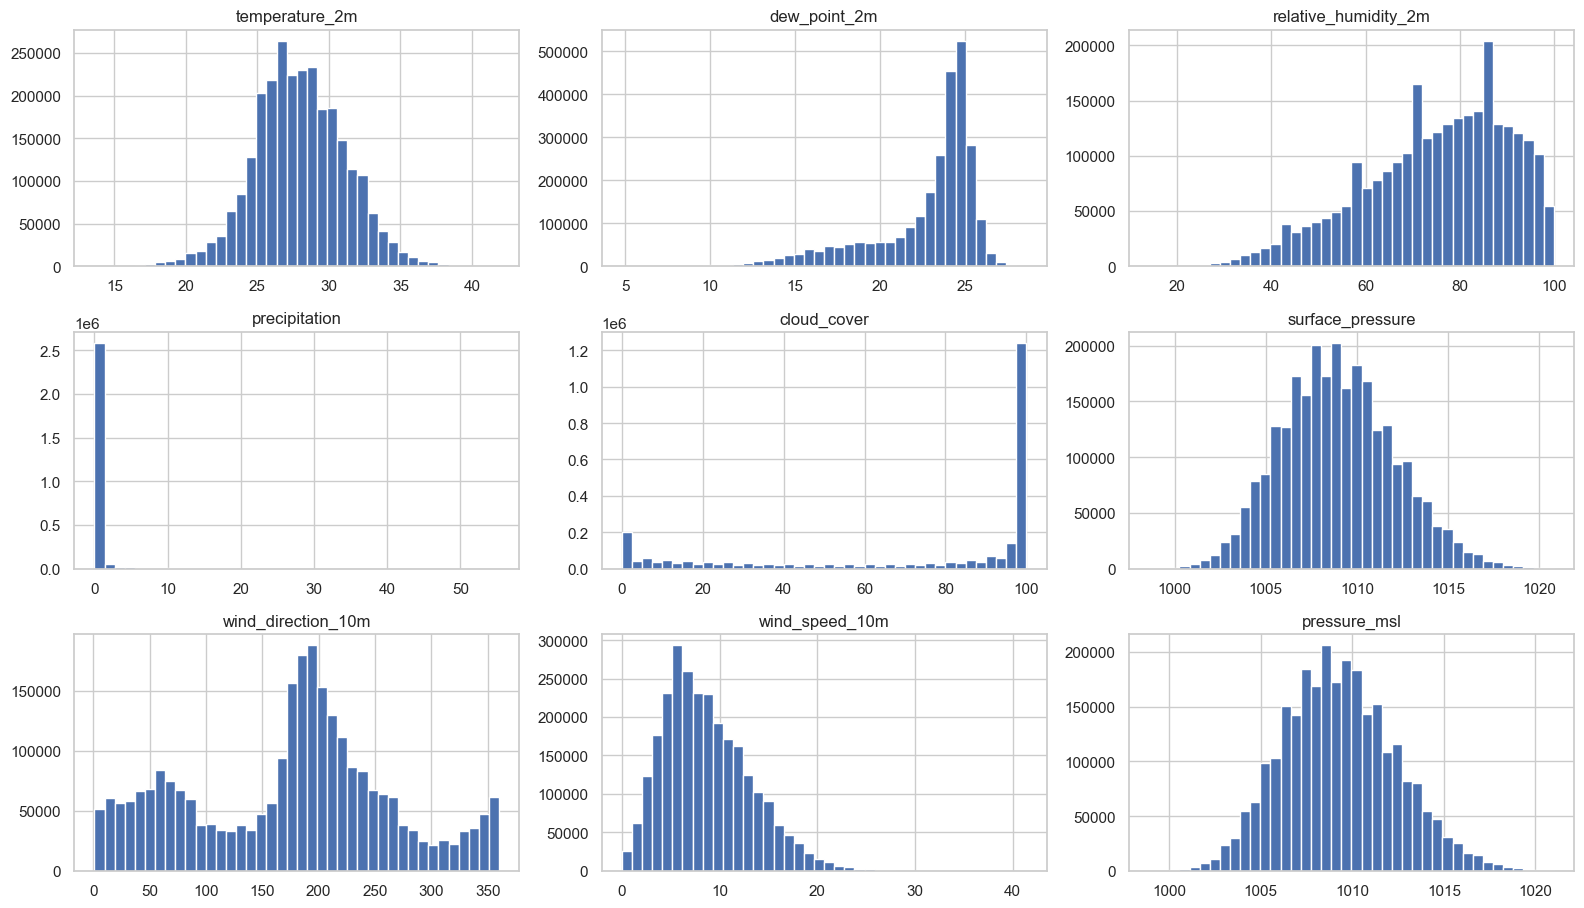

In [43]:
df[available_weather_columns].hist(bins=40, figsize=(16, 12), layout=(4, 3))
plt.tight_layout()
plt.show()

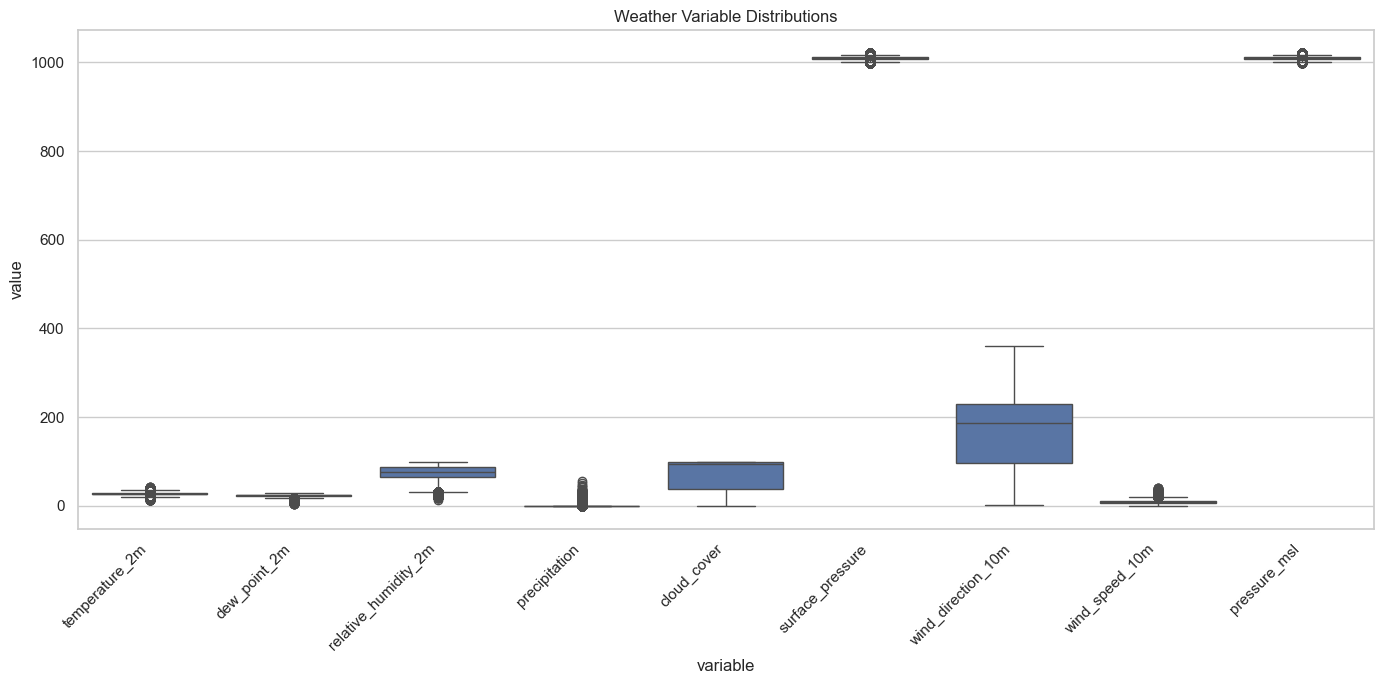

In [44]:
long_weather_df = df[available_weather_columns].melt(var_name="variable", value_name="value")

plt.figure(figsize=(14, 7))
sns.boxplot(data=long_weather_df, x="variable", y="value")
plt.xticks(rotation=45, ha="right")
plt.title("Weather Variable Distributions")
plt.tight_layout()
plt.show()

## 7. Precipitation Overview

In [45]:
precip_summary = df["precipitation"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame()
precip_summary.loc["rain_rate"] = df["rain_flag"].mean()
precip_summary

,precipitation
count,2688000.000
mean,0.197
std,0.871
min,0.000
50%,0.000
75%,0.000
90%,0.300
95%,1.000
99%,4.300
max,55.300


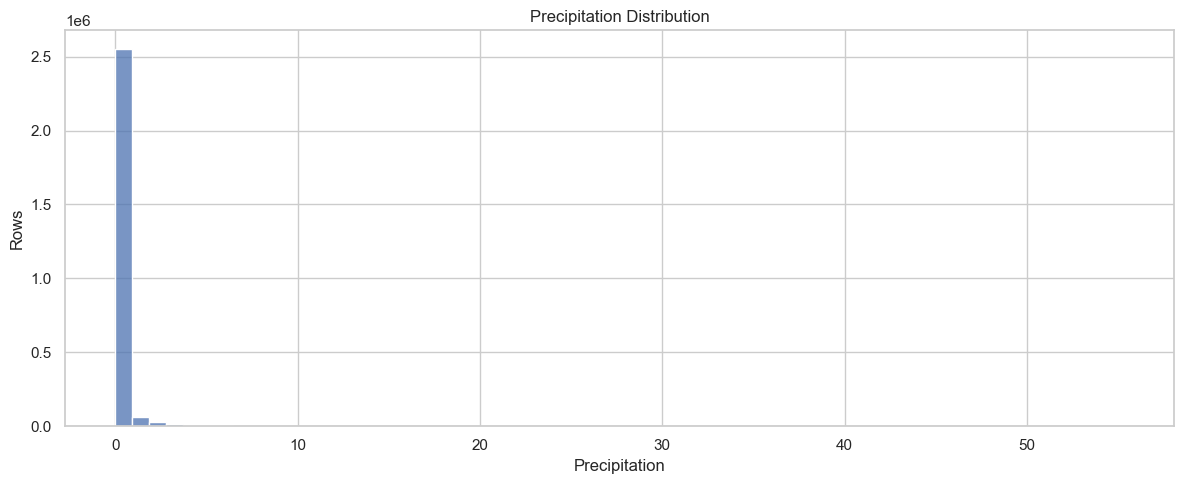

In [46]:
plt.figure(figsize=(12, 5))
sns.histplot(df["precipitation"].dropna(), bins=60)
plt.title("Precipitation Distribution")
plt.xlabel("Precipitation")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

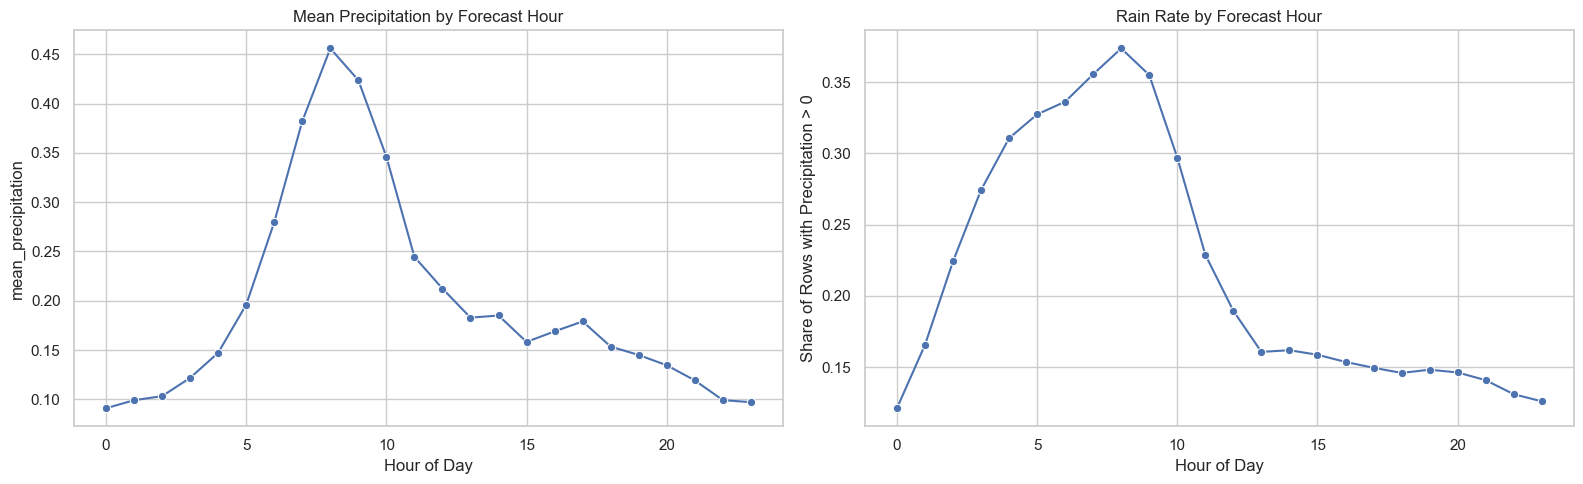

In [47]:
hourly_rain = (
    df.groupby("forecast_hour", as_index=False)
    .agg(
        mean_precipitation=("precipitation", "mean"),
        rain_rate=("rain_flag", "mean"),
        row_count=("precipitation", "size"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=hourly_rain, x="forecast_hour", y="mean_precipitation", marker="o", ax=axes[0])
axes[0].set_title("Mean Precipitation by Forecast Hour")
axes[0].set_xlabel("Hour of Day")

sns.lineplot(data=hourly_rain, x="forecast_hour", y="rain_rate", marker="o", ax=axes[1])
axes[1].set_title("Rain Rate by Forecast Hour")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Share of Rows with Precipitation > 0")

plt.tight_layout()
plt.show()

## 8. Time-Series Trends

Hourly data across multiple years can look like one solid block. This section keeps an hourly summary for reference, then creates daily summaries and smoothed trend lines so patterns are easier to read.

In [48]:
hourly_summary = (
    df.set_index("forecast_time")
    .sort_index()
    .resample("1h")
    .agg(
        mean_temperature=("temperature_2m", "mean"),
        mean_dew_point=("dew_point_2m", "mean"),
        mean_humidity=("relative_humidity_2m", "mean"),
        mean_precipitation=("precipitation", "mean"),
        max_precipitation=("precipitation", "max"),
        rain_rate=("rain_flag", "mean"),
        grid_count=("grid_number", "nunique"),
    )
    .reset_index()
)

daily_summary = (
    df.set_index("forecast_time")
    .sort_index()
    .resample("1D")
    .agg(
        mean_temperature=("temperature_2m", "mean"),
        mean_dew_point=("dew_point_2m", "mean"),
        mean_humidity=("relative_humidity_2m", "mean"),
        mean_precipitation=("precipitation", "mean"),
        total_precipitation=("precipitation", "sum"),
        max_precipitation=("precipitation", "max"),
        rain_rate=("rain_flag", "mean"),
        grid_count=("grid_number", "nunique"),
    )
    .reset_index()
)

rolling_window_days = 14
for column in ["mean_temperature", "mean_dew_point", "mean_humidity", "rain_rate", "mean_precipitation", "total_precipitation"]:
    daily_summary[f"{column}_{rolling_window_days}d_avg"] = (
        daily_summary[column]
        .rolling(window=rolling_window_days, min_periods=1)
        .mean()
    )

daily_summary.head()

,forecast_time,mean_temperature,mean_dew_point,mean_humidity,mean_precipitation,total_precipitation,max_precipitation,rain_rate,grid_count,mean_temperature_14d_avg,mean_dew_point_14d_avg,mean_humidity_14d_avg,rain_rate_14d_avg,mean_precipitation_14d_avg,total_precipitation_14d_avg
0,2021-01-01 00:00:00+00:00,22.220,13.090,56.989,0.000,0.000,0.000,0.000,56,22.220,13.090,56.989,0.000,0.000,0.000
1,2021-01-02 00:00:00+00:00,22.493,14.735,62.499,0.000,0.000,0.000,0.000,56,22.356,13.912,59.744,0.000,0.000,0.000
2,2021-01-03 00:00:00+00:00,24.309,16.147,61.474,0.000,0.000,0.000,0.000,56,23.007,14.657,60.320,0.000,0.000,0.000
3,2021-01-04 00:00:00+00:00,25.610,17.810,62.958,0.000,0.000,0.000,0.000,56,23.658,15.445,60.980,0.000,0.000,0.000
4,2021-01-05 00:00:00+00:00,26.093,19.486,68.100,0.000,0.000,0.000,0.000,56,24.145,16.254,62.404,0.000,0.000,0.000


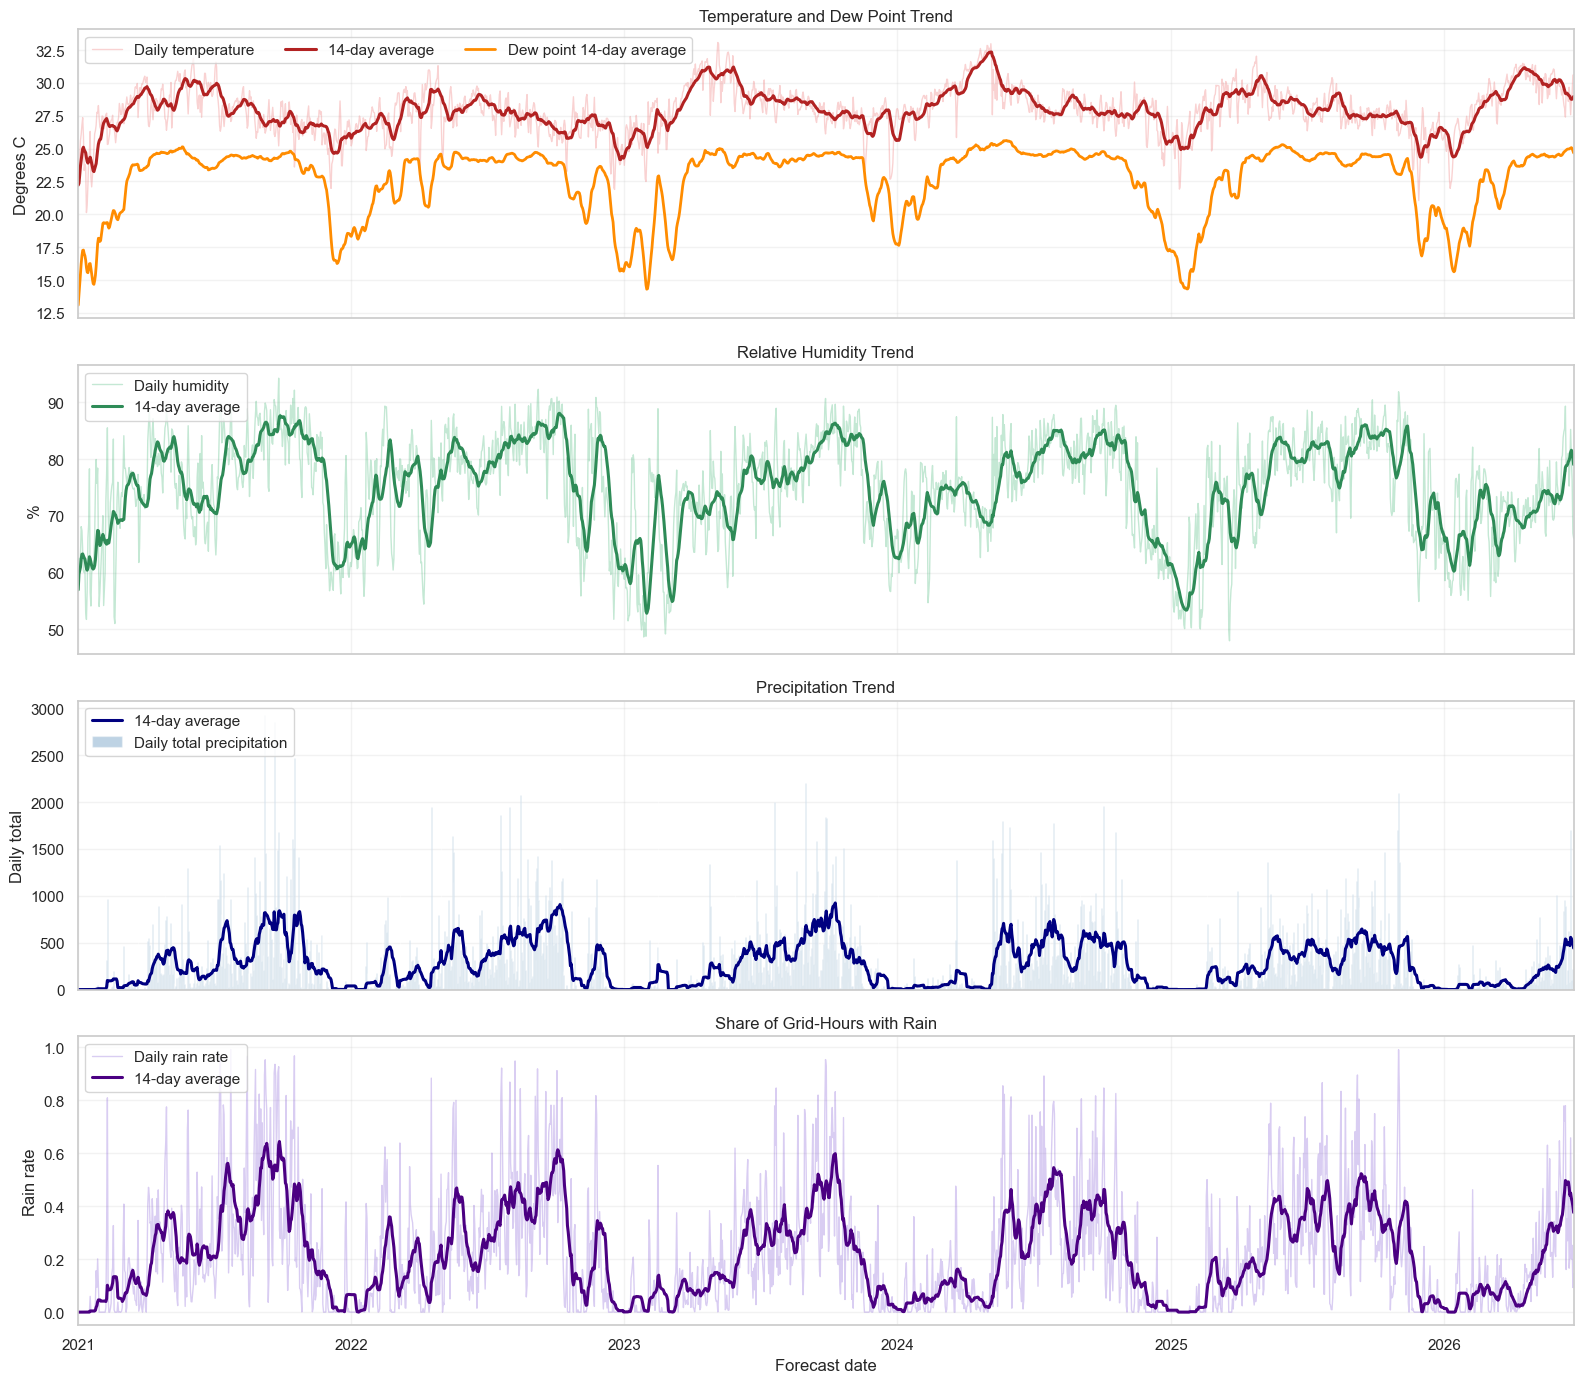

In [49]:
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

sns.lineplot(
    data=daily_summary,
    x="forecast_time",
    y="mean_temperature",
    ax=axes[0],
    color="lightcoral",
    alpha=0.35,
    linewidth=1,
    label="Daily temperature",
)
sns.lineplot(
    data=daily_summary,
    x="forecast_time",
    y=f"mean_temperature_{rolling_window_days}d_avg",
    ax=axes[0],
    color="firebrick",
    linewidth=2.2,
    label=f"{rolling_window_days}-day average",
)
sns.lineplot(
    data=daily_summary,
    x="forecast_time",
    y=f"mean_dew_point_{rolling_window_days}d_avg",
    ax=axes[0],
    color="darkorange",
    linewidth=2,
    label=f"Dew point {rolling_window_days}-day average",
)
axes[0].set_title("Temperature and Dew Point Trend")
axes[0].set_ylabel("Degrees C")
axes[0].legend(loc="upper left", ncol=3)

sns.lineplot(
    data=daily_summary,
    x="forecast_time",
    y="mean_humidity",
    ax=axes[1],
    color="mediumseagreen",
    alpha=0.3,
    linewidth=1,
    label="Daily humidity",
)
sns.lineplot(
    data=daily_summary,
    x="forecast_time",
    y=f"mean_humidity_{rolling_window_days}d_avg",
    ax=axes[1],
    color="seagreen",
    linewidth=2.2,
    label=f"{rolling_window_days}-day average",
)
axes[1].set_title("Relative Humidity Trend")
axes[1].set_ylabel("%")
axes[1].legend(loc="upper left")

axes[2].bar(
    daily_summary["forecast_time"],
    daily_summary["total_precipitation"],
    width=1.0,
    color="steelblue",
    alpha=0.35,
    label="Daily total precipitation",
)
sns.lineplot(
    data=daily_summary,
    x="forecast_time",
    y=f"total_precipitation_{rolling_window_days}d_avg",
    ax=axes[2],
    color="navy",
    linewidth=2.2,
    label=f"{rolling_window_days}-day average",
)
axes[2].set_title("Precipitation Trend")
axes[2].set_ylabel("Daily total")
axes[2].legend(loc="upper left")

sns.lineplot(
    data=daily_summary,
    x="forecast_time",
    y="rain_rate",
    ax=axes[3],
    color="mediumpurple",
    alpha=0.35,
    linewidth=1,
    label="Daily rain rate",
)
sns.lineplot(
    data=daily_summary,
    x="forecast_time",
    y=f"rain_rate_{rolling_window_days}d_avg",
    ax=axes[3],
    color="indigo",
    linewidth=2.2,
    label=f"{rolling_window_days}-day average",
)
axes[3].set_title("Share of Grid-Hours with Rain")
axes[3].set_ylabel("Rain rate")
axes[3].set_xlabel("Forecast date")
axes[3].legend(loc="upper left")

for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.margins(x=0)

plt.tight_layout()
plt.show()

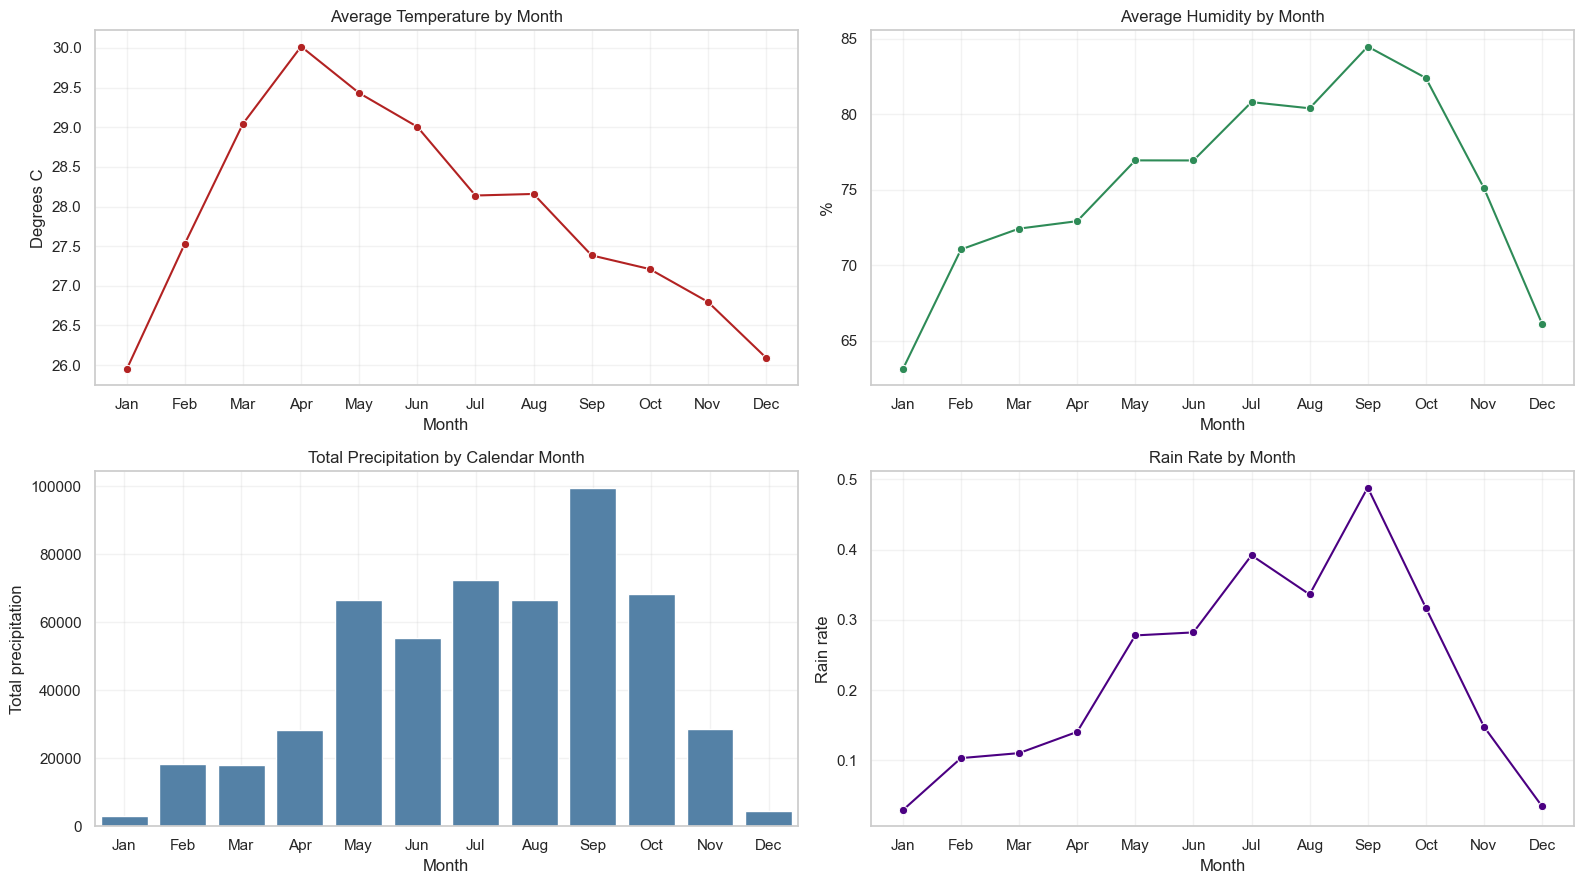

,month,mean_temperature,mean_humidity,total_precipitation,mean_precipitation,rain_rate,month_name
0,1,25.950,63.128,3061.000,0.012,0.029,Jan
1,2,27.534,71.049,18229.200,0.080,0.103,Feb
2,3,29.045,72.427,18085.800,0.072,0.110,Mar
3,4,30.018,72.921,28204.000,0.117,0.140,Apr
4,5,29.431,76.943,66630.700,0.267,0.278,May
5,6,29.006,76.938,55372.000,0.238,0.282,Jun
6,7,28.139,80.799,72445.000,0.348,0.392,Jul
7,8,28.159,80.390,66582.500,0.320,0.336,Aug
8,9,27.384,84.477,99441.600,0.493,0.488,Sep
9,10,27.212,82.398,68462.500,0.329,0.317,Oct


In [50]:
monthly_seasonality = (
    df.assign(month=df["forecast_time"].dt.month)
    .groupby("month", as_index=False)
    .agg(
        mean_temperature=("temperature_2m", "mean"),
        mean_humidity=("relative_humidity_2m", "mean"),
        total_precipitation=("precipitation", "sum"),
        mean_precipitation=("precipitation", "mean"),
        rain_rate=("rain_flag", "mean"),
    )
)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_seasonality["month_name"] = pd.Categorical(
    monthly_seasonality["month"].map(dict(enumerate(month_labels, start=1))),
    categories=month_labels,
    ordered=True,
)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

sns.lineplot(data=monthly_seasonality, x="month_name", y="mean_temperature", marker="o", ax=axes[0], color="firebrick")
axes[0].set_title("Average Temperature by Month")
axes[0].set_ylabel("Degrees C")

sns.lineplot(data=monthly_seasonality, x="month_name", y="mean_humidity", marker="o", ax=axes[1], color="seagreen")
axes[1].set_title("Average Humidity by Month")
axes[1].set_ylabel("%")

sns.barplot(data=monthly_seasonality, x="month_name", y="total_precipitation", ax=axes[2], color="steelblue")
axes[2].set_title("Total Precipitation by Calendar Month")
axes[2].set_ylabel("Total precipitation")

sns.lineplot(data=monthly_seasonality, x="month_name", y="rain_rate", marker="o", ax=axes[3], color="indigo")
axes[3].set_title("Rain Rate by Month")
axes[3].set_ylabel("Rain rate")

for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.set_xlabel("Month")

plt.tight_layout()
plt.show()

monthly_seasonality

## 9. Grid-Level Patterns

In [51]:
grid_summary = (
    df.groupby(["grid_number", "grid_row", "grid_column", "longitude", "latitude"], as_index=False)
    .agg(
        row_count=("forecast_time", "size"),
        mean_temperature=("temperature_2m", "mean"),
        mean_humidity=("relative_humidity_2m", "mean"),
        total_precipitation=("precipitation", "sum"),
        mean_precipitation=("precipitation", "mean"),
        rain_rate=("rain_flag", "mean"),
        max_precipitation=("precipitation", "max"),
    )
    .sort_values("total_precipitation", ascending=False)
)

grid_summary.head(15)

,grid_number,grid_row,grid_column,longitude,latitude,row_count,mean_temperature,mean_humidity,total_precipitation,mean_precipitation,rain_rate,max_precipitation
47,48,6,8,100.910,13.901,48000,27.588,76.289,11055.700,0.230,0.230,21.600
55,56,7,8,100.910,13.955,48000,27.598,76.253,10915.100,0.227,0.226,21.200
39,40,5,8,100.910,13.820,48000,27.682,75.901,10793.800,0.225,0.229,24.800
54,55,7,7,100.826,13.955,48000,27.628,76.170,10782.100,0.225,0.223,22.000
46,47,6,7,100.826,13.901,48000,27.680,75.967,10625.100,0.221,0.225,20.400
53,54,7,6,100.743,13.955,48000,27.751,75.449,10393.100,0.217,0.220,20.600
38,39,5,7,100.826,13.820,48000,27.790,75.435,10265.200,0.214,0.228,21.200
45,46,6,6,100.743,13.901,48000,27.784,75.615,10264.600,0.214,0.221,23.600
50,51,7,3,100.493,13.955,48000,27.958,74.818,10217.400,0.213,0.208,24.200
31,32,4,8,100.910,13.738,48000,27.801,75.412,10159.500,0.212,0.227,25.500


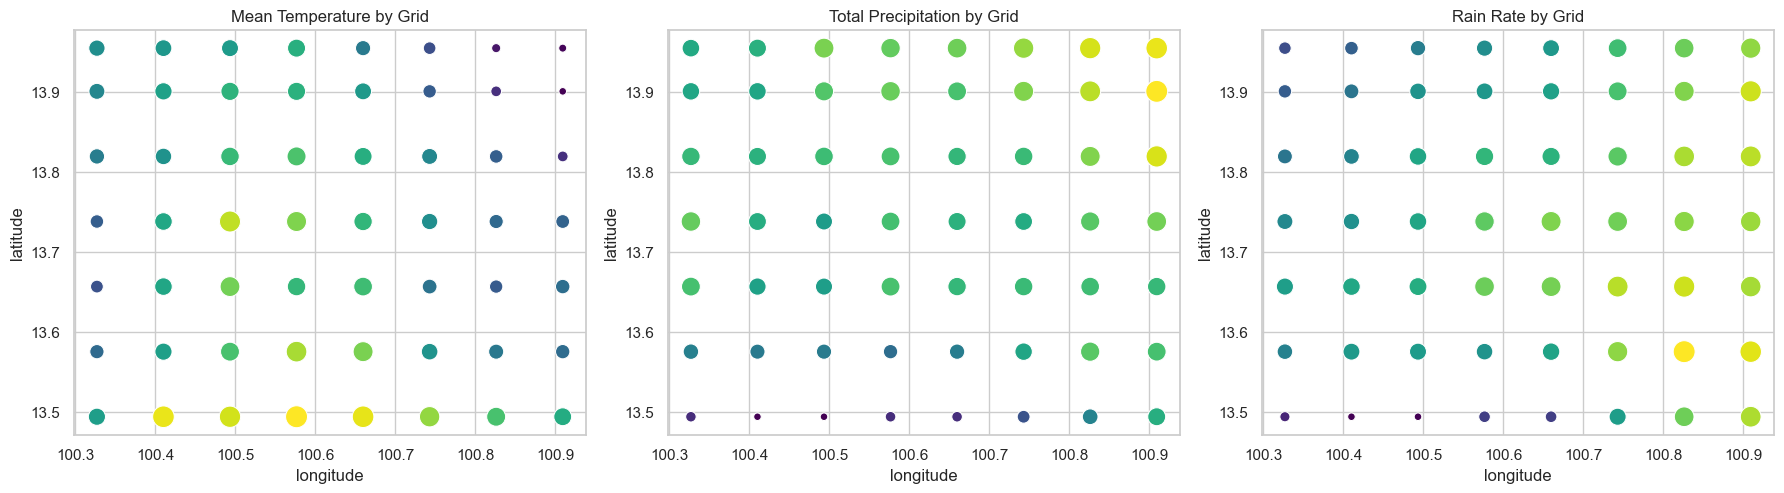

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, column, title in [
    (axes[0], "mean_temperature", "Mean Temperature by Grid"),
    (axes[1], "total_precipitation", "Total Precipitation by Grid"),
    (axes[2], "rain_rate", "Rain Rate by Grid"),
]:
    plot = sns.scatterplot(
        data=grid_summary,
        x="longitude",
        y="latitude",
        hue=column,
        size=column,
        sizes=(30, 250),
        palette="viridis",
        ax=ax,
        legend=False,
    )
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

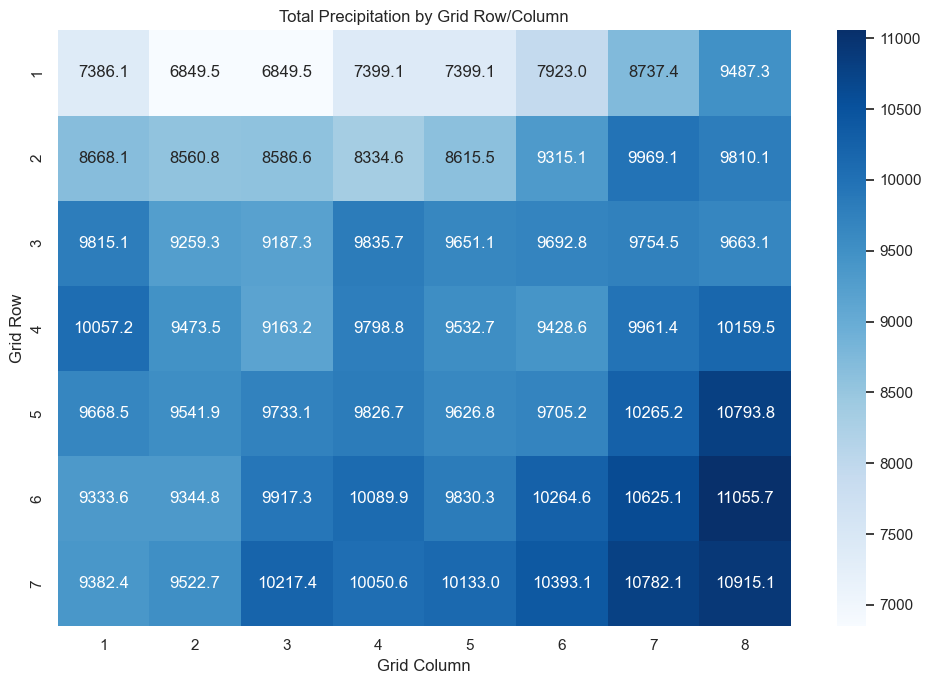

In [53]:
pivot_precip = grid_summary.pivot(index="grid_row", columns="grid_column", values="total_precipitation")

plt.figure(figsize=(10, 7))
sns.heatmap(pivot_precip, cmap="Blues", annot=True, fmt=".1f")
plt.title("Total Precipitation by Grid Row/Column")
plt.xlabel("Grid Column")
plt.ylabel("Grid Row")
plt.tight_layout()
plt.show()

## 10. Correlation-Based Lag Feature Selection

Goal: find the top 3 actual database weather variables with the strongest relationship to `precipitation`. These are the best first candidates for lag features.

No engineered features are created or ranked in this notebook. The correlation analysis only uses columns loaded directly from `"New_BKK_Data"`, after dropping `cape` and `convective_inhibition` from the analysis dataframe.

In [54]:
TARGET_COLUMN = "precipitation"

candidate_feature_columns = [
    column
    for column in available_weather_columns
    if column != TARGET_COLUMN and column in df.columns
]

correlation_input = df[[TARGET_COLUMN, *candidate_feature_columns]].dropna()

correlation_results = (
    correlation_input
    .corr(numeric_only=True)[TARGET_COLUMN]
    .drop(labels=[TARGET_COLUMN])
    .rename("correlation_with_precipitation")
    .to_frame()
    .assign(abs_correlation=lambda data: data["correlation_with_precipitation"].abs())
    .sort_values("abs_correlation", ascending=False)
)

top_3_lag_candidates = correlation_results.head(3).copy()
top_3_lag_variables = top_3_lag_candidates.index.tolist()

print("Top 3 DB variables to consider for lag features:")
for rank, (variable, row) in enumerate(top_3_lag_candidates.iterrows(), start=1):
    direction = "positive" if row["correlation_with_precipitation"] >= 0 else "negative"
    print(
        f"{rank}. {variable}: "
        f"corr={row['correlation_with_precipitation']:.3f}, "
        f"abs_corr={row['abs_correlation']:.3f}, "
        f"direction={direction}"
    )

correlation_results

Top 3 DB variables to consider for lag features:
1. cloud_cover: corr=0.155, abs_corr=0.155, direction=positive
2. relative_humidity_2m: corr=0.150, abs_corr=0.150, direction=positive
3. dew_point_2m: corr=0.121, abs_corr=0.121, direction=positive


,correlation_with_precipitation,abs_correlation
cloud_cover,0.155,0.155
relative_humidity_2m,0.150,0.150
dew_point_2m,0.121,0.121
surface_pressure,-0.112,0.112
pressure_msl,-0.112,0.112
temperature_2m,-0.050,0.050
wind_speed_10m,0.047,0.047
wind_direction_10m,0.027,0.027


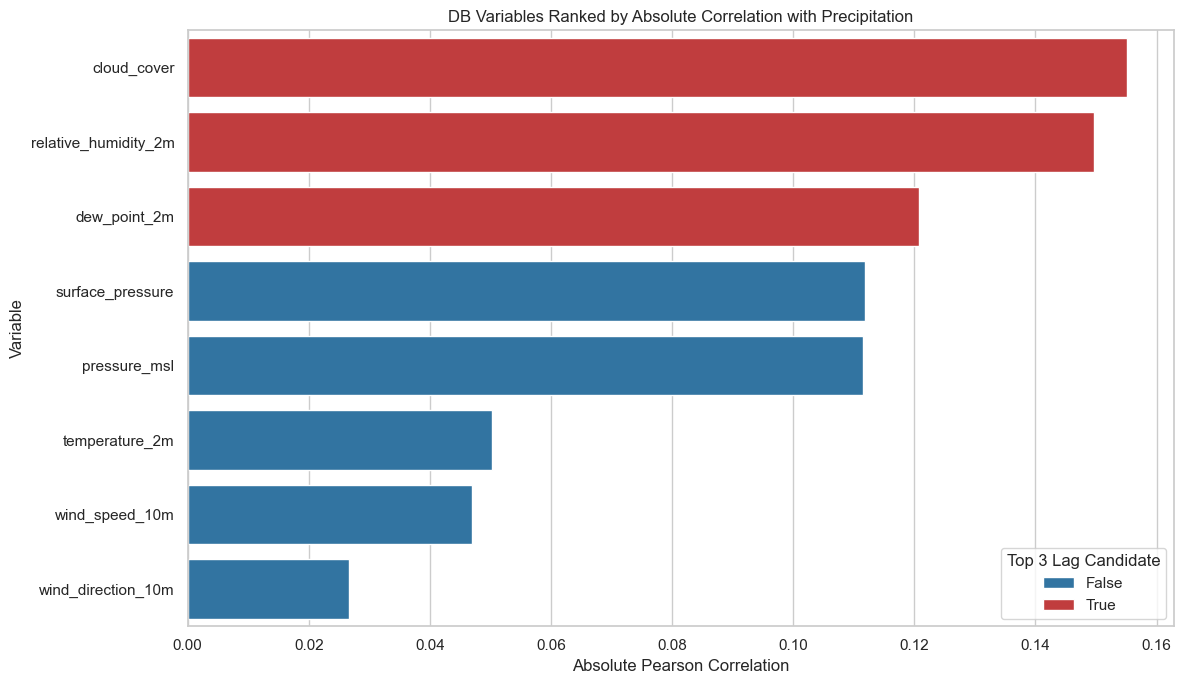

In [55]:
plt.figure(figsize=(12, 7))
plot_df = correlation_results.reset_index().rename(columns={"index": "variable"})

sns.barplot(
    data=plot_df,
    y="variable",
    x="abs_correlation",
    hue=plot_df["variable"].isin(top_3_lag_variables),
    dodge=False,
    palette={True: "tab:red", False: "tab:blue"},
)
plt.title("DB Variables Ranked by Absolute Correlation with Precipitation")
plt.xlabel("Absolute Pearson Correlation")
plt.ylabel("Variable")
plt.legend(title="Top 3 Lag Candidate", loc="lower right")
plt.tight_layout()
plt.show()

In [57]:
lag_hours_to_test = [1, 2, 3, 4, 5, 6, 24, 48]
recommended_lag_features = [
    f"{variable}_lag_{hour}h"
    for variable in top_3_lag_variables
    for hour in lag_hours_to_test
]

print("Recommended lag feature variables:")
print(top_3_lag_variables)
print("Recommended lag feature columns to test:")
for feature in recommended_lag_features:
    print(feature)

Recommended lag feature variables:
['cloud_cover', 'relative_humidity_2m', 'dew_point_2m']
Recommended lag feature columns to test:
cloud_cover_lag_1h
cloud_cover_lag_2h
cloud_cover_lag_3h
cloud_cover_lag_4h
cloud_cover_lag_5h
cloud_cover_lag_6h
cloud_cover_lag_24h
cloud_cover_lag_48h
relative_humidity_2m_lag_1h
relative_humidity_2m_lag_2h
relative_humidity_2m_lag_3h
relative_humidity_2m_lag_4h
relative_humidity_2m_lag_5h
relative_humidity_2m_lag_6h
relative_humidity_2m_lag_24h
relative_humidity_2m_lag_48h
dew_point_2m_lag_1h
dew_point_2m_lag_2h
dew_point_2m_lag_3h
dew_point_2m_lag_4h
dew_point_2m_lag_5h
dew_point_2m_lag_6h
dew_point_2m_lag_24h
dew_point_2m_lag_48h


## 11. Validate Candidate Lag Features

After selecting the top 3 current-time variables, this section checks whether their lagged values relate to current precipitation for a well-populated grid. This helps confirm whether the lag idea is useful before adding the features to a model pipeline.

In [ ]:
selected_grid = df["grid_number"].value_counts().idxmax()
lag_df = (
    df[df["grid_number"] == selected_grid]
    .sort_values("forecast_time")
    .set_index("forecast_time")
    .copy()
)

for column in top_3_lag_variables:
    for lag_hour in lag_hours_to_test:
        lag_df[f"{column}_lag_{lag_hour}h"] = lag_df[column].shift(lag_hour)

lag_df["current_precipitation"] = lag_df["precipitation"]
lag_df.tail()

In [ ]:
lag_corr_columns = [column for column in lag_df.columns if "_lag_" in column]
lag_feature_correlations = (
    lag_df[["current_precipitation", *lag_corr_columns]]
    .corr(numeric_only=True)["current_precipitation"]
    .drop(labels=["current_precipitation"])
    .rename("correlation_with_current_precipitation")
    .to_frame()
    .assign(abs_correlation=lambda data: data["correlation_with_current_precipitation"].abs())
    .sort_values("abs_correlation", ascending=False)
)

lag_feature_correlations.head(20)

## 12. Close Connection

In [ ]:
conn.close()
print("Connection closed")